In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import cv2
import matplotlib.animation as animation

from tqdm import tqdm

In [19]:
skip = 1

image_folder = "Images_p"
velocity_folder = "Velocities_p"

speed_min = float('inf')
speed_max = 0

u_min = float('inf')
u_max = 0

v_min = float('inf')
v_max = 0

for s in range(0, 510, skip):
    u_path = f"{velocity_folder}/U_{s}.dat"
    v_path = f"{velocity_folder}/V_{s}.dat"

    if not os.path.exists(u_path) or not os.path.exists(v_path):
        continue

    U = np.loadtxt(u_path)
    V = np.loadtxt(v_path)

    speed = np.sqrt(U**2 + V**2)

    speed_max = max(speed_max, speed.max())
    speed_min = min(speed_min, speed.min())

    u_max = max(u_max, U.max())
    u_min = min(u_min, U.min())

    v_max = max(v_max, V.max())
    v_min = min(v_min, V.min())



In [20]:
video_name = 'output_video_21_p.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 24

video = None

mag_levels = np.linspace(speed_min, speed_max, 20).round(2)
u_levels = np.linspace(u_min, u_max, 20).round(2)
v_levels = np.linspace(v_min, v_max, 20).round(2)

for s in tqdm(range(0, 510, 1)):

    u_path = f"{velocity_folder}/U_{s}.dat"
    v_path = f"{velocity_folder}/V_{s}.dat"
    img_path = f"{image_folder}/img_{s}.png"

    if not (os.path.exists(u_path) and os.path.exists(v_path) and os.path.exists(img_path)):
        continue

    U = np.loadtxt(u_path)
    V = np.loadtxt(v_path)

    img = np.array(
        Image.open(img_path)
        .convert("RGB")
        .resize((U.shape[1], U.shape[0]))
    )

    x = np.linspace(0, 1, U.shape[1])
    y = np.linspace(0, 1, U.shape[0])
    X, Y = np.meshgrid(x, y)

    speed = np.sqrt(U**2 + V**2)

    fig, axs = plt.subplots(1, 5, figsize=(20, 4))

    # 1. Original image
    axs[0].imshow(img)
    axs[0].set_title("Image")
    axs[0].axis('off')

    # 2. U velocity
    cf1 = axs[1].contourf(X, Y, U, levels=u_levels, cmap='seismic')
    axs[1].set_title("U velocity")
    axs[1].invert_yaxis()
    plt.colorbar(cf1, ax=axs[1])

    # 3. V velocity
    cf2 = axs[2].contourf(X, Y, -V, levels=v_levels, cmap='seismic')
    axs[2].set_title("V velocity")
    axs[2].invert_yaxis()
    plt.colorbar(cf2, ax=axs[2])

    # 4. Magnitude
    cf3 = axs[3].contourf(X, Y, speed, levels=mag_levels, cmap='jet')
    axs[3].set_title("|Velocity|")
    axs[3].invert_yaxis()
    plt.colorbar(cf3, ax=axs[3])

    # 5️. Quiver
    # axs[4].imshow(img, extent=[0, 1, 1, 0], alpha=0.5)

    step = 5
    axs[4].quiver(
        X[::step, ::step],
        Y[::step, ::step],
        U[::step, ::step],
        -V[::step, ::step],
        color='black',
        scale=10   
    )
    axs[4].set_title("Quiver")
    axs[4].invert_yaxis()

    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()


    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    plt.close(fig)

    if video is None:
        h, w, _ = frame.shape
        video = cv2.VideoWriter(video_name, fourcc, fps, (w, h))

    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    video.write(frame)

if video is not None:
    video.release()

print("Video saved!")

100%|██████████| 510/510 [00:16<00:00, 30.18it/s]

Video saved!


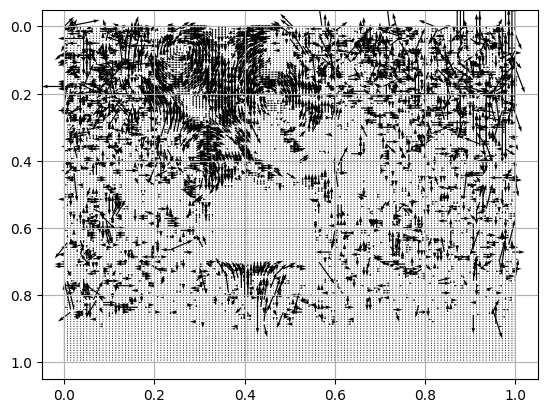

In [72]:
plt.quiver(X, Y, U, -V)
plt.gca().invert_yaxis()
plt.grid()
plt.show()

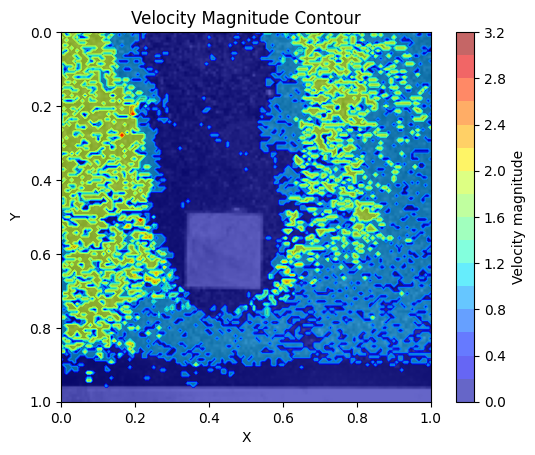

In [112]:
speed = np.sqrt(U**2 + V**2)

plt.imshow(
    before_img,
    alpha=1.0,
    extent=[X.min(), X.max(), Y.max(), Y.min()], 
    zorder=1
)

plt.contourf(
    X, Y, speed,
    levels=20,
    cmap='jet',
    alpha=0.6,
    zorder=2
)

plt.colorbar(label="Velocity magnitude")

plt.title("Velocity Magnitude Contour")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()